---
---

# Screentime & Mental Wellness
---
---

<div class="alert alert-block alert-warning">
Adapt the headline in the cell above!
</div>

<div class="alert alert-block alert-warning">

Present a short summary of the pitch!

(Add up to 5 bullet points in the cell below)
</div>

* Data on Mental wellness and Lifestyle choices, including screentime habits 
* Project: Recognizing User Groups by clustering data
* Goal: Finding solutions to mental wellness problems targeted towards certain groups based on behavior
* Societal Value: Greater well-being in the population, decreasing mental health problems
* Monetary Value: Potentially higher productivity when average mental wellness is higher


# Imports and Settings
---
<div class="alert alert-block alert-warning">
Use the following code cell to organize all imports and global settings.
Do not remove the pandas option.
    
(Commented code, in the next cell)
</div>

In [1]:
import pandas as pd
# make pandas display ALL columns of a dataframe
pd.options.display.max_columns = None
import numpy as np

# Plotting and visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Scaling and Dimensionality reduction
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import VarianceThreshold

# Clusterings
from sklearn.cluster import OPTICS, cluster_optics_dbscan

# Evaluation 
from sklearn.metrics import mutual_info_score
from sklearn.metrics.cluster import rand_score

# Task 1 -- The Data

<div class="alert alert-block alert-warning">
Present the origin of the dataset, including e.g.
    
* the source where you got it from (link to the repository),
* the author(s),
* the license,
* the purpose for which it was collected!

(Add bullet points in the cell below)
</div>

* The dataset is called "Screen Time vs Mental Wellness Survey - 2025" and is from Kaggle 
* Link: https://www.kaggle.com/datasets/adharshinikumar/screentime-vs-mentalwellness-survey-2025
* Author: Adharshini Kumaresan
* Licence: MIT licence
* Licence excerpt: "Permission is hereby granted, free of charge, to any person obtaining a copy of this software and associated documentation files (the "Software"), to deal in the Software without restriction, including without limitation the rights to use, copy, modify, merge, publish, distribute, sublicense" licence must be provided for this 
* Purpose of collection: Analyzing and understanding the connection between screentime habits and mental wellness 


## The Raw Data
<div class="alert alert-block alert-warning"> 

Load the data and present a couple of samples. Call the dataset variable <code>raw_data</code>.

(Commented code, add cells below)
</div>


In [2]:
# loading the data
raw_data = pd.read_csv("ScreenTimevsMentalWellness.csv")

In [3]:
# first samples
raw_data.head()

,user_id,age,gender,occupation,work_mode,screen_time_hours,work_screen_hours,leisure_screen_hours,sleep_hours,sleep_quality_1_5,stress_level_0_10,productivity_0_100,exercise_minutes_per_week,social_hours_per_week,mental_wellness_index_0_100,Unnamed: 15
0,U0001,33,Female,Employed,Remote,10.79,5.44,5.35,6.63,1,9.3,44.7,127,0.7,9.3,NaN
1,U0002,28,Female,Employed,In-person,7.40,0.37,7.03,8.05,3,5.7,78.0,74,2.1,56.2,NaN
2,U0003,35,Female,Employed,Hybrid,9.78,1.09,8.69,6.48,1,9.1,51.8,67,8.0,3.6,NaN
3,U0004,42,Male,Employed,Hybrid,11.13,0.56,10.57,6.89,1,10.0,37.0,0,5.7,0.0,NaN
4,U0005,28,Male,Student,Remote,13.22,4.09,9.13,5.79,1,10.0,38.5,143,10.1,0.0,NaN


In [4]:
# a few more samples
raw_data.tail()

,user_id,age,gender,occupation,work_mode,screen_time_hours,work_screen_hours,leisure_screen_hours,sleep_hours,sleep_quality_1_5,stress_level_0_10,productivity_0_100,exercise_minutes_per_week,social_hours_per_week,mental_wellness_index_0_100,Unnamed: 15
395,U0396,26,Female,Student,Remote,6.43,2.99,3.44,7.75,1,5.9,64.6,252,7.6,39.3,NaN
396,U0397,16,Male,Self-employed,Remote,9.59,5.44,4.15,5.57,1,10.0,47.4,99,7.0,3.5,NaN
397,U0398,40,Male,Student,Remote,8.72,2.36,6.36,7.56,1,9.4,57.3,193,10.1,6.6,NaN
398,U0399,29,Female,Retired,Hybrid,5.04,0.94,4.10,7.32,1,7.1,63.6,97,12.1,21.0,NaN
399,U0400,39,Female,Employed,Remote,8.86,3.82,5.04,6.55,1,10.0,41.4,88,9.8,8.4,NaN


<div class="alert alert-block alert-warning"> 
Explain the dataset with all its features.
    
* The features should be described in the following table. The range is the set of possible values that a feature can take, e.g. "red, green, blue", "$\mathbb{R}$", "$1,2,...,12$".
* You may describe each feature individually or groups of features, if many features are similar (whatever is easier to explain.)

(Fill in the table, add bullet points in the next cell)
</div>

* The dataset has various features on screentime and lifestyle habits, as well as mental wellness factors
* The below table shows the ranges the values take in the dataset
* For all features given in minutes and hours, numbers could range up to a reasonable number of hours a day or week; there is no fixed limit, which is why the range from the dataset is given in the table




| Feature | Range  | Explanation |
|---------|--------|-------------|
|user_id  |U0001-U0400 | Id for each User    |
|age  |16-60 | Age of the User     |
|gender  |Female, Male, Non-binary/Other| Gender of the User     |
|occupation  |Employed, Unemployed, Student, Retired, Self-employed | Employment status of the User     |
|work_mode  |Remote, In-person, Hybrid| Mode how user works    |
|screen_time_hours  |1.0-19.17| Hours a user spents at a screen per day   |
|work_screen_hours  |0.11-12.04| Hours a user spents at a screen for work per day   |
|leisure_screen_hours  |0.89-13.35| Hours a user spents at a screen for leisure per day   |
|sleep_hours  |4.64-9.74| Hours a user sleeps per day   |
|sleep_quality |1-5| Own sleep quality ranked by user   |
|stress_level_0_10  |0-10| Own stress level ranked by user  |
|productivity_0_100  |0-100| Own productivity ranked by user   |
|exercise_minutes_per_week  |0-372| Minutes a user spents exercising a week  |
|social_hours_per_week  |0.0-23.9| Hours a user spents socializing a week   |
|mental_wellness_index_0_100  |0-100| Own mental wellness ranked by user    |
|Unnamed: 15  |NaN| Filler column without any information    |

<div class="alert alert-block alert-warning">
Explain why the dataset is suitable for the pitched task!
    
(Add up 3 bullet points in the cell below)
</div>

* The data is up to date, as it was collected in 2025
* It shows a variety of features on the topic, like screentime per day and mental wellness index
* A lot of data is numerical and in fixed ranges, making it comparable

# Task 2 -- Initial Data Analysis

<div class="alert alert-block alert-warning"> 
<b>Initial Data Analysis (IDA)</b>: Present relevant quantities about the data.
    
(Commented Code + bullet points, add cells below)
</div>

In [5]:
# looking at the shape of the data 
print(raw_data.shape)

(400, 16)


In [6]:
# Looking for NaN values 
print(raw_data.isnull().sum())

user_id                          0
age                              0
gender                           0
occupation                       0
work_mode                        0
screen_time_hours                0
work_screen_hours                0
leisure_screen_hours             0
sleep_hours                      0
sleep_quality_1_5                0
stress_level_0_10                0
productivity_0_100               0
exercise_minutes_per_week        0
social_hours_per_week            0
mental_wellness_index_0_100      0
Unnamed: 15                    400
dtype: int64


In [7]:
# checking for duplicates, sum() counts the True values
raw_data.duplicated().sum() 

np.int64(0)

In [8]:
# Checking for outliers in the data that are not logically possible
print((raw_data["age"] > 100).sum()) # checking for too high ages
print((raw_data["age"] < 16).sum()) # checking wether very young ages occur
print((raw_data["screen_time_hours"] > 20).sum()) # assuming at least 4 hours of sleep 
print((raw_data["work_screen_hours"] > 20).sum()) # assuming at least 4 hours of sleep 
print((raw_data["leisure_screen_hours"] > 20).sum()) # assuming at least 4 hours of sleep 
print((raw_data["sleep_hours"] > 10).sum()) # checking for too high sleep counts
print((raw_data["sleep_quality_1_5"].isin(range(1,6))).sum()) # checking wether all data is in allowed range of 1-5
print((raw_data["stress_level_0_10"] > 10).sum()) # checking wether data is above allowed range
print((raw_data["stress_level_0_10"] < 0).sum()) # checking wether data is below allowed range (negative)
print((raw_data["productivity_0_100"] > 100).sum()) # checking wether data is above allowed range
print((raw_data["productivity_0_100"] < 0).sum())# checking wether data is below allowed range (negative)
print((raw_data["exercise_minutes_per_week"] > 390).sum()) # assuming 6.5 hours a week for a start (more can still be logical) --> no further experiments needed, as all values are within 5 hours a week
print((raw_data["social_hours_per_week"] > 35).sum()) # assuming 4 hours a day for a start (more can still be logical) --> no further experiments needed, as all values are within 35 hours 
print((raw_data["mental_wellness_index_0_100"] > 100).sum())# checking wether data is above allowed range 
print((raw_data["mental_wellness_index_0_100"] < 0).sum())# checking wether data is below allowed range (negative)

0
0
0
0
0
0
400
0
0
0
0
0
0
0
0


In [9]:
# looking at datatypes 
print(raw_data.dtypes)

user_id                         object
age                              int64
gender                          object
occupation                      object
work_mode                       object
screen_time_hours              float64
work_screen_hours              float64
leisure_screen_hours           float64
sleep_hours                    float64
sleep_quality_1_5                int64
stress_level_0_10              float64
productivity_0_100             float64
exercise_minutes_per_week        int64
social_hours_per_week          float64
mental_wellness_index_0_100    float64
Unnamed: 15                    float64
dtype: object


Observations:
* There are 400 rows and 16 columns in the raw data
* There are no NaN values in the data
* There are no duplicates in the data 
* There are no logical outliers (numbers too high for the hours in a day/week or out of range)
* There are a lot of numerical features, 9 are floats, 3 ints and the rest categorical

# Task 3 -- Preprocessing

<div class="alert alert-block alert-warning"> 
Conduct all steps of Task 3. Call the result <code>data_full</code>.
    
(Commented code + bullet points, add cells below)
</div>

<div class="alert alert-block alert-warning"> 
<b>Remember</b>: The dataset must now be final with respect to the included columns and rows.
</div>

In [10]:
# dropping columns
raw_data.drop(columns= ["user_id", "gender", "occupation", "work_mode", "Unnamed: 15"], inplace=True)

* Dropped columns: user_id, gender, occupation, work_mode, Unnamed: 15
* user_id: redundant with the index
* Unnamed: 15: does not contain any viable information
* gender: no gender seperation wanted
* occupation: I do not want to rate the different forms of occupation and I do not want to differentiate between them
* work_mode: not important for my analysis wether the screentime happens in remote, hybrid or at work

In [11]:
# dataframe after dropping columns
raw_data.head()

,age,screen_time_hours,work_screen_hours,leisure_screen_hours,sleep_hours,sleep_quality_1_5,stress_level_0_10,productivity_0_100,exercise_minutes_per_week,social_hours_per_week,mental_wellness_index_0_100
0,33,10.79,5.44,5.35,6.63,1,9.3,44.7,127,0.7,9.3
1,28,7.40,0.37,7.03,8.05,3,5.7,78.0,74,2.1,56.2
2,35,9.78,1.09,8.69,6.48,1,9.1,51.8,67,8.0,3.6
3,42,11.13,0.56,10.57,6.89,1,10.0,37.0,0,5.7,0.0
4,28,13.22,4.09,9.13,5.79,1,10.0,38.5,143,10.1,0.0


In [12]:
# transforming exercise column from minutes to hours
raw_data["exercise_hours_per_week"] = round(raw_data["exercise_minutes_per_week"] / 60,2)

In [13]:
raw_data.drop(columns=["exercise_minutes_per_week"], inplace = True) # dropping original exercise column
raw_data.head()

,age,screen_time_hours,work_screen_hours,leisure_screen_hours,sleep_hours,sleep_quality_1_5,stress_level_0_10,productivity_0_100,social_hours_per_week,mental_wellness_index_0_100,exercise_hours_per_week
0,33,10.79,5.44,5.35,6.63,1,9.3,44.7,0.7,9.3,2.12
1,28,7.40,0.37,7.03,8.05,3,5.7,78.0,2.1,56.2,1.23
2,35,9.78,1.09,8.69,6.48,1,9.1,51.8,8.0,3.6,1.12
3,42,11.13,0.56,10.57,6.89,1,10.0,37.0,5.7,0.0,0.00
4,28,13.22,4.09,9.13,5.79,1,10.0,38.5,10.1,0.0,2.38


* Transformed exercise minutes to exercise hours to make it more comparable with other columns (all other time frames are hours)
* No further preprocessing needed, as there were no NaN values, duplicates or not logical outliers

In [14]:
# Calling the result data_full
data_full = raw_data 

In [15]:
# Checking shape of data_full
data_full.shape

(400, 11)

* Final shape of data_full: 400 rows with 11 features left

# Task 4 -- Exploratory Data Analysis

<div class="alert alert-block alert-warning"> 
Present 3 highlights from the exploratory data analysis in your draft.

(Commented code + bullet points, add cells below under the respective hightlight headlines)

## EDA Highlight 1

**Visualization of Correlation**

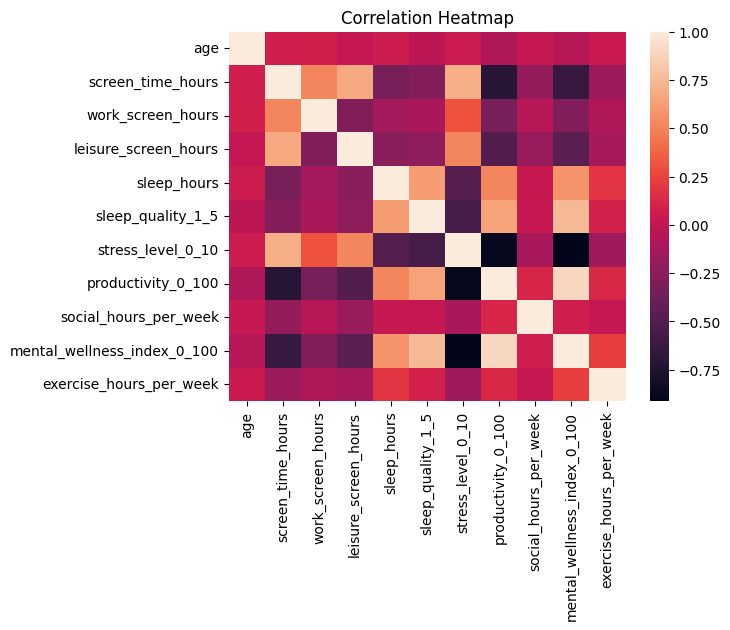

In [16]:
# correlation between colummns 
data_full.corr()
# correlation heatmap to visualize above correlation
sns.heatmap(data_full.corr())
plt.title("Correlation Heatmap")
plt.show()

Observation:
* Some strong correlations
* stress level and mental wellness index with a strong negative correlation
* stress level and productivity 
* productivity and mental wellness index with fairly strong positive correlation of about 0.8-0.9 
* screentime hours and the mental wellness index with a fairly strong negative correlation 
* screen time hours and productivity with an even stronger negative correlation between screen time hours and productivity
* Does not mean causation but can be an indicator for where to look closer

## EDA Highlight 2

**Distribution of each feature**

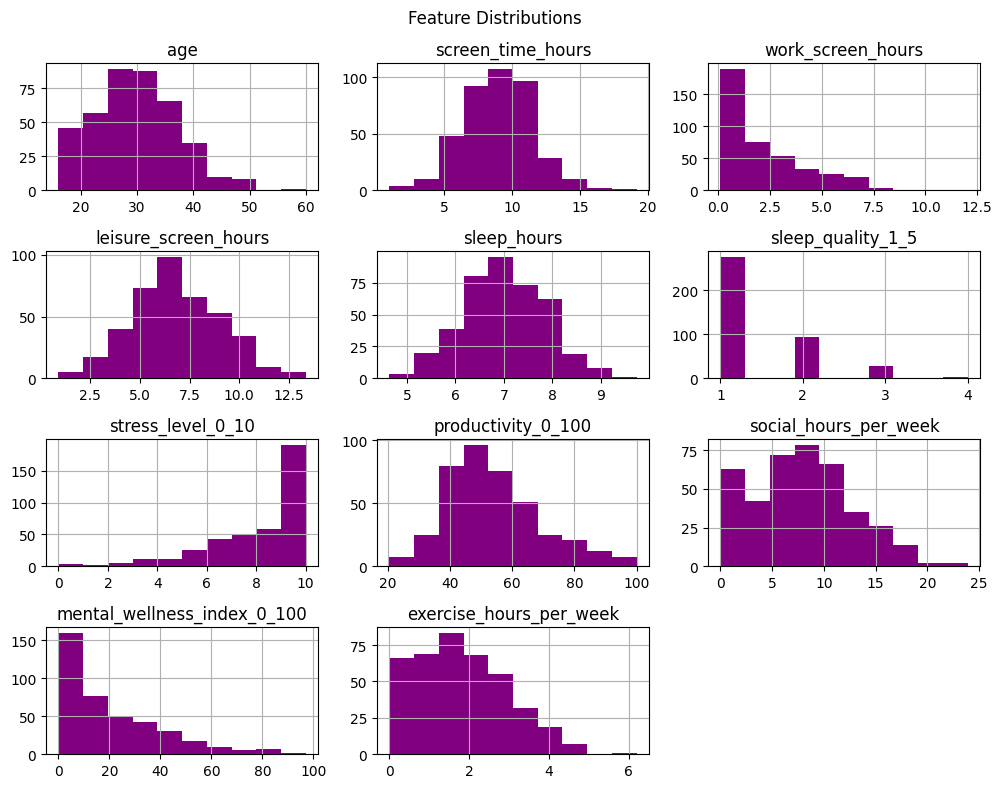

In [17]:
# Plotting the distribution of each feature
data_full.hist(figsize=(10, 8), color = "purple")
plt.suptitle("Feature Distributions")
plt.tight_layout()
plt.show()

Observation:
* how the values are distributed across each feature
* Example: many people reportet a stress lebel of 9-10 and only a few a stresslevel between 0 and 6
* For mental wellness index the graph looks the same just mirrored, with many people reporting a low mental wellness index and only few a higher one
* --> Can see correlations again when knowing where to look

## EDA Highlight 3

**Boxplot of all Features**

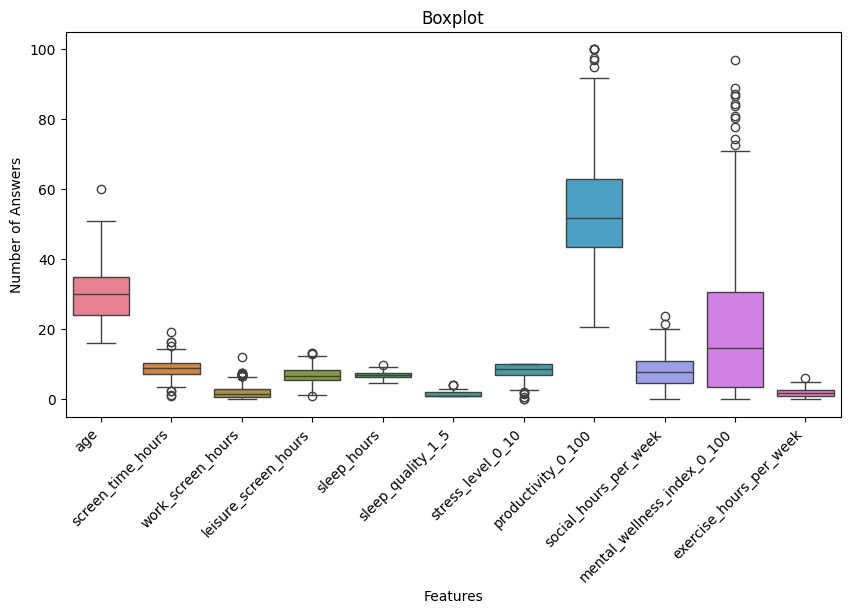

In [18]:
# Box plots
plt.figure(figsize=(10, 5))
sns.boxplot(data=data_full)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Features")
plt.ylabel("Number of Answers")
plt.title("Boxplot")
plt.show()

Observation:
* shows how the features are distributes on one scale
* also show the outliers (most in mental wellness index and productivity)
* mental wellness index and productivity have the largest range

# Task 5 -- Dimensionality Reduction with PCA

<div class="alert alert-block alert-warning"> 
<b>PCA</b>: 
Conduct your analyses and transformations according to Task 5.
Call the transformed dataset <code>data_pca</code>.

(Commented code + bullet points, add cells below)
</div>

In [19]:
# Scaling the data with a standard scaler for PCA
scaler = StandardScaler()
 
scaled_data = scaler.fit_transform(data_full) #.fit and transform data 
print(type(scaled_data))
scaled_data = pd.DataFrame(scaled_data, index=data_full.index, columns=data_full.columns) # transform into dataframe to visualize 
scaled_data.round(2)

<class 'numpy.ndarray'>


,age,screen_time_hours,work_screen_hours,leisure_screen_hours,sleep_hours,sleep_quality_1_5,stress_level_0_10,productivity_0_100,social_hours_per_week,mental_wellness_index_0_100,exercise_hours_per_week
0,0.43,0.71,1.69,-0.67,-0.45,-0.61,0.55,-0.64,-1.47,-0.54,0.25
1,-0.24,-0.65,-0.94,0.08,1.22,2.46,-1.17,1.58,-1.18,1.76,-0.51
2,0.70,0.30,-0.57,0.83,-0.63,-0.61,0.45,-0.17,0.02,-0.82,-0.61
3,1.64,0.85,-0.84,1.68,-0.14,-0.61,0.88,-1.15,-0.45,-1.00,-1.57
4,-0.24,1.69,0.99,1.03,-1.44,-0.61,0.88,-1.05,0.45,-1.00,0.47
...,...,...,...,...,...,...,...,...,...,...,...
395,-0.51,-1.04,0.42,-1.53,0.87,-0.61,-1.08,0.69,-0.06,0.93,2.03
396,-1.85,0.23,1.69,-1.21,-1.70,-0.61,0.88,-0.46,-0.18,-0.83,-0.15
397,1.37,-0.12,0.09,-0.22,0.64,-0.61,0.60,0.20,0.45,-0.67,1.19
398,-0.10,-1.60,-0.64,-1.24,0.36,-0.61,-0.50,0.62,0.86,0.03,-0.18


In [20]:
# Doing PCA on full data without specifying where to cut yet
model_full = PCA()

full_pca = model_full.fit_transform(scaled_data) # fitting and transforming on scaled data 
print(full_pca.shape)
full_pca=pd.DataFrame(full_pca, index=data_full.index) # transforming into dataframe for better visualization
full_pca.round(2)

(400, 11)


,0,1,2,3,4,5,6,7,8,9,10
0,-1.52,1.63,-0.74,-0.27,0.99,-1.10,-0.08,-0.10,0.04,0.04,-0.0
1,3.34,-1.05,-1.89,-0.96,-0.51,-0.37,-0.21,0.63,0.03,0.03,0.0
2,-1.34,-0.76,0.24,0.44,-0.78,-0.49,-0.14,-0.07,0.32,-0.23,0.0
3,-2.43,-1.21,-0.77,0.74,-1.87,-0.94,0.39,-0.11,-0.21,0.03,0.0
4,-2.85,0.33,-0.02,0.13,0.39,0.98,-1.13,-0.17,0.00,-0.11,-0.0
...,...,...,...,...,...,...,...,...,...,...,...
395,2.18,1.00,0.64,0.55,2.08,-0.00,0.39,-0.78,-0.06,0.15,-0.0
396,-1.64,1.49,1.28,-1.94,1.35,0.17,-0.45,0.57,0.23,-0.01,-0.0
397,-0.25,0.62,0.08,1.91,0.25,-0.03,0.66,-0.12,0.75,-0.18,0.0
398,1.47,0.13,1.80,0.15,-0.17,-0.36,0.88,-0.06,0.15,-0.11,0.0


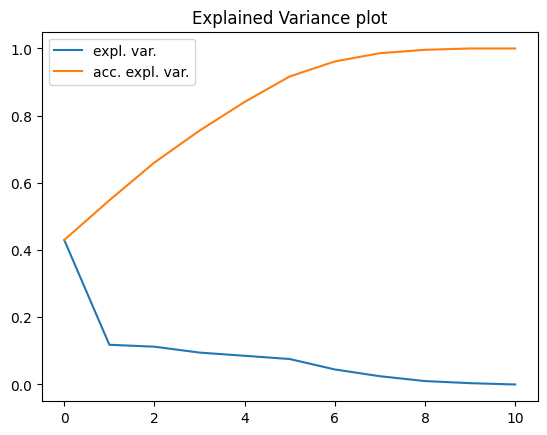

In [21]:
# visualizing explained variance to make an informed decision on threshold for reduction
expl_var=model_full.explained_variance_ratio_
plt.plot(expl_var, label="expl. var.") # plotting explained variance
plt.plot(np.add.accumulate(expl_var), label="acc. expl. var.") # plotting accumulated explained variance
plt.legend()
plt.title("Explained Variance plot")
plt.show()

Observation/Reasoning: 
* keeping features to retain 90% of variance
* curve of the accumulated explained variance is flattening around that point
* following features only contribute slightly to the variance
* 90% is a reasonable cut off point, as it finds a balance between reducing dimensionality and retaining enough information.
* 6 features will be left after reducing 

In [22]:
# applying chosen percentage of variance to retain
model = PCA(n_components=0.9) 

results = model.fit_transform(scaled_data) # fitting and transforming on scaled data 
data_pca=pd.DataFrame(results, index=data_full.index) # transforming into dataframe for better visualization
data_pca.round(2)

,0,1,2,3,4,5
0,-1.52,1.63,-0.74,-0.27,0.99,-1.10
1,3.34,-1.05,-1.89,-0.96,-0.51,-0.37
2,-1.34,-0.76,0.24,0.44,-0.78,-0.49
3,-2.43,-1.21,-0.77,0.74,-1.87,-0.94
4,-2.85,0.33,-0.02,0.13,0.39,0.98
...,...,...,...,...,...,...
395,2.18,1.00,0.64,0.55,2.08,-0.00
396,-1.64,1.49,1.28,-1.94,1.35,0.17
397,-0.25,0.62,0.08,1.91,0.25,-0.03
398,1.47,0.13,1.80,0.15,-0.17,-0.36


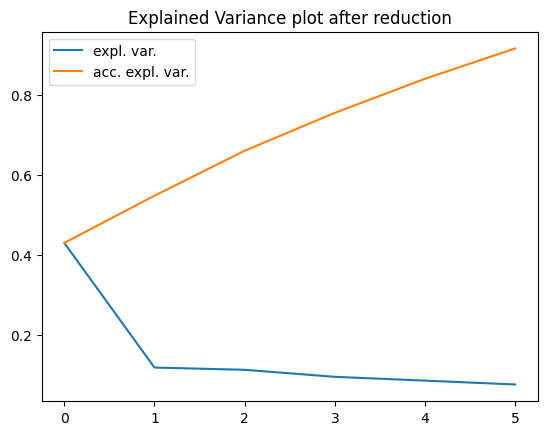

In [23]:
expl_var=model.explained_variance_ratio_
plt.plot(expl_var, label="expl. var.") # plotting explained variance 
plt.plot(np.add.accumulate(expl_var), label="acc. expl. var.") # plotting accumulated explained variance 
plt.title("Explained Variance plot after reduction")
plt.legend()
plt.show()

In [24]:
# Looking at the resulting dataframe
data_pca

,0,1,2,3,4,5
0,-1.516088,1.633153,-0.742973,-0.267694,0.992134,-1.096053
1,3.335179,-1.046002,-1.887513,-0.960593,-0.514111,-0.368210
2,-1.340107,-0.761850,0.240498,0.437206,-0.776821,-0.485198
3,-2.432252,-1.213348,-0.766600,0.743020,-1.865696,-0.941303
4,-2.851507,0.325344,-0.022223,0.134638,0.394718,0.982382
...,...,...,...,...,...,...
395,2.183963,1.002397,0.642337,0.554746,2.083680,-0.002405
396,-1.640048,1.494806,1.284010,-1.944436,1.345379,0.172282
397,-0.250051,0.620777,0.078586,1.910466,0.252167,-0.029004
398,1.471060,0.131464,1.800757,0.152451,-0.167126,-0.362568


* 6 features are left after pca
* 90% of variance is retained with those features

# Task 6 -- Dimensionality Reduction by Feature Selection

<div class="alert alert-block alert-warning"> 
<b>PCA</b>: 
Conduct your analyses and transformations according to Task 5.
Call the transformed dataset <code>data_vt</code>.

(Commented code + bullet points, add cells below)
</div>

In [25]:
# Using MinMaxScaler to preserve variance but scale the data 
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(data_full) # fitting and transforming 
scaled_data = pd.DataFrame(scaled_data, columns=data_full.columns) # transforming into dataframe 
scaled_data.head()

,age,screen_time_hours,work_screen_hours,leisure_screen_hours,sleep_hours,sleep_quality_1_5,stress_level_0_10,productivity_0_100,social_hours_per_week,mental_wellness_index_0_100,exercise_hours_per_week
0,0.386364,0.538800,0.446773,0.357945,0.390196,0.000000,0.93,0.303526,0.029289,0.095876,0.341935
1,0.272727,0.352229,0.021794,0.492777,0.668627,0.666667,0.57,0.722922,0.087866,0.579381,0.198387
2,0.431818,0.483214,0.082146,0.626003,0.360784,0.000000,0.91,0.392947,0.334728,0.037113,0.180645
3,0.590909,0.557512,0.037720,0.776886,0.441176,0.000000,1.00,0.206549,0.238494,0.000000,0.000000
4,0.272727,0.672537,0.333613,0.661316,0.225490,0.000000,1.00,0.225441,0.422594,0.000000,0.383871


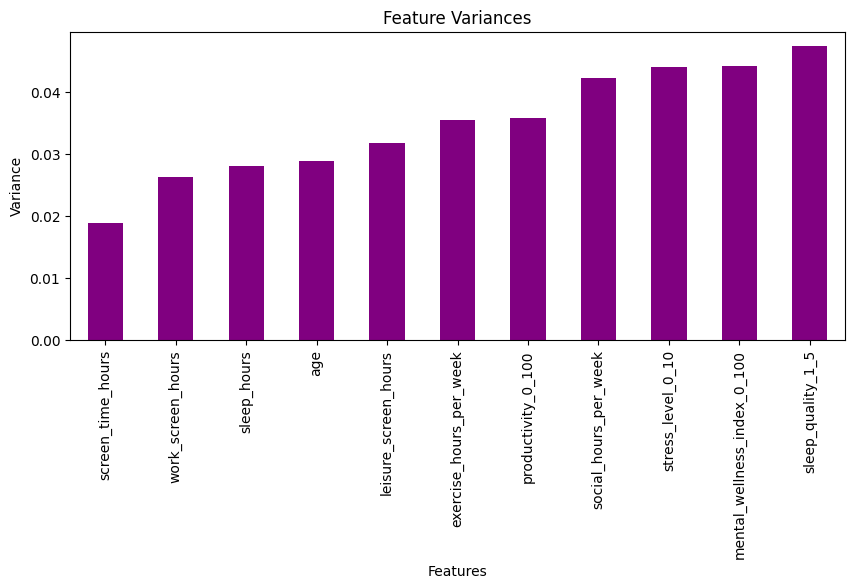

In [26]:
# Visualizing the variance across the features of the scaled data for an informed decision on threshold for reduction
variances = scaled_data.var()
variances.sort_values().plot(kind='bar', figsize=(10,4), color="purple") # plotting variances
plt.xlabel("Features")
plt.ylabel("Variance")
plt.title("Feature Variances")
plt.show()

Observation/Reasoning:
* the 4 features with the highest variance all have a variance above 0.04
* clear step can be seen between the fourth highest feature, social hours per week and the fifth highest variance feature, productivity_0_100
* MinMaxScaler makes the variance comparable
* Therefore use that clear cut in visualization as threshold for the dimensionality reduction by feature selection
* All other features below 0.04 have too little variance

In [27]:
# Doing Feature reduction with variance threshold
variances = scaled_data.var()

sorted_vars = variances.sort_values(ascending=False) # sorting the values in descending order 

#Choosing the 4 featues with the most variance
threshold = sorted_vars.iloc[4]

selector = VarianceThreshold(threshold=threshold) 
reduced_data = selector.fit_transform(scaled_data) # fitting and transforming on scaled data

# Making lists to evaluate kept and cut features
kept_mask = selector.get_support()
kept_features = data_full.columns[kept_mask].tolist()
discarded_features = data_full.columns[~kept_mask].tolist()

# Looking at which features were kept and discarded
print("Kept:", kept_features)
print("Discarded:", discarded_features)

Kept: ['sleep_quality_1_5', 'stress_level_0_10', 'social_hours_per_week', 'mental_wellness_index_0_100']
Discarded: ['age', 'screen_time_hours', 'work_screen_hours', 'leisure_screen_hours', 'sleep_hours', 'productivity_0_100', 'exercise_hours_per_week']


In [28]:
# Transforming reduced data into a dataframe to visualize; renaming to final name
data_vt=pd.DataFrame(reduced_data, index=data_full.index, columns=kept_features)

In [29]:
# Final data_vt dataframe after dimensionality reduction with feature selection
data_vt

,sleep_quality_1_5,stress_level_0_10,social_hours_per_week,mental_wellness_index_0_100
0,0.000000,0.93,0.029289,0.095876
1,0.666667,0.57,0.087866,0.579381
2,0.000000,0.91,0.334728,0.037113
3,0.000000,1.00,0.238494,0.000000
4,0.000000,1.00,0.422594,0.000000
...,...,...,...,...
395,0.000000,0.59,0.317992,0.405155
396,0.000000,1.00,0.292887,0.036082
397,0.000000,0.94,0.422594,0.068041
398,0.000000,0.71,0.506276,0.216495


* 4 features are left in the dataframe 

# Task 7 -- Clustering

<div class="alert alert-block alert-warning"> 
<b>Choice of Algorithm</b>: 
Given the situation in the pitch and the results from the above analyses. Which algorithm (chosen from the three families a) $k$-Means/$k$-Means++, b) OPTICS, and c) HAC) would <b>YOU</b> choose for the clustering? Explain!
    
(Choice + 1-3 bullet points in the cell below)
</div>

My Choice: OPTICS on data_vt

* Most precise clusters and accurate filtering of noise
* Can be visualized with higher dimensions
* OPTICS fits scaling and dimensionality reduction of data_vt 

<div class="alert alert-block alert-danger"> 
<b>Requirements</b>: 
In the following and for the remainder of the final phase of the exam (indenpendent of what your choice above suggests):

* use the algorithm <b>OPTICS</b> (as Algorithm $A$).
* for each version of the dataset, select a clustering by discussing different choices of <b>distance cuts</b> of the OPTICS reachability diagram. Select exactly one distance cut for each dataset version.
* call the respective cluster assignments <code>labels_full</code>, <code>labels_pca</code>, and <code>labels_vt</code> respectively.
</div>

## Comprehensive clustering analysis
<div class="alert alert-block alert-warning"> 
<b>Clustering</b>: 
On both datasets, data and data_pca, under their respective headlines below, conduct comprehensive clustering analyses with algorithm $A$ (OPTICS, see above). Conduct ALL necessary steps to create the most helpful and meaningful clustering per dataset version. Use appropriate diagrams to demonstrate the results. 
</div>

### Clustering Analysis of plain data

<div class="alert alert-block alert-warning"> 
<b>Choice of Distance Function</b>: 
Choose the distance function for the plain data clustering. Explain!
    
(Choice + 1-3 bullet points in the cell below)
</div>

My Choice: Cosine Similarity

* Not sensible to magnitudes --> scaling not as important 
* Works well with higher dimensionalities 
* Focus on Grouping based on behaviour, not magnitude of values

<div class="alert alert-block alert-warning"> 
Clustering of <code>data_full</code>:

(Commented code + bullet points, add cells below)
</div>

**Reachability plot**

* Reachbility plot to visualize OPTICS reachability 
* Using parameters derived from experiments in the draft 

Number of clusters: 4


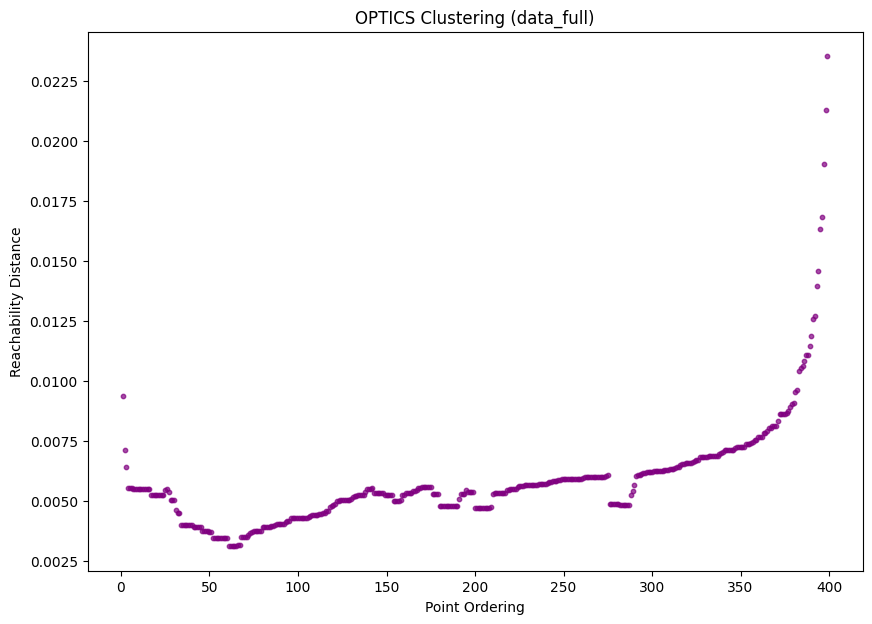

In [30]:
optics = OPTICS(min_samples=15, min_cluster_size=0.025, metric="cosine") # parameter values derived from draft 
optics_clusters=optics.fit_predict(data_full) # fitting and predicting
clusters = np.unique(optics_clusters) # unique cluster labels
num_c = len(clusters) - 1 if -1 in clusters else len(clusters) # number of clusters, -1 is always noise
print(f"Number of clusters: {num_c}") # print the number of clusters

ordered_labels = optics.labels_[optics.ordering_] # ordering the labels
reachability = optics.reachability_[optics.ordering_] # calculating reachability
space = np.arange(len(data_full))
plt.figure(figsize=(10, 7))
plt.scatter(space, reachability, s=10, alpha=0.7, color="purple") # plot reachability pot
plt.xlabel("Point Ordering")
plt.ylabel("Reachability Distance")
plt.title("OPTICS Clustering (data_full)")
plt.show()

**Distance Cuts**

Number of Clusters: 5 for Epsilon Value 0.005


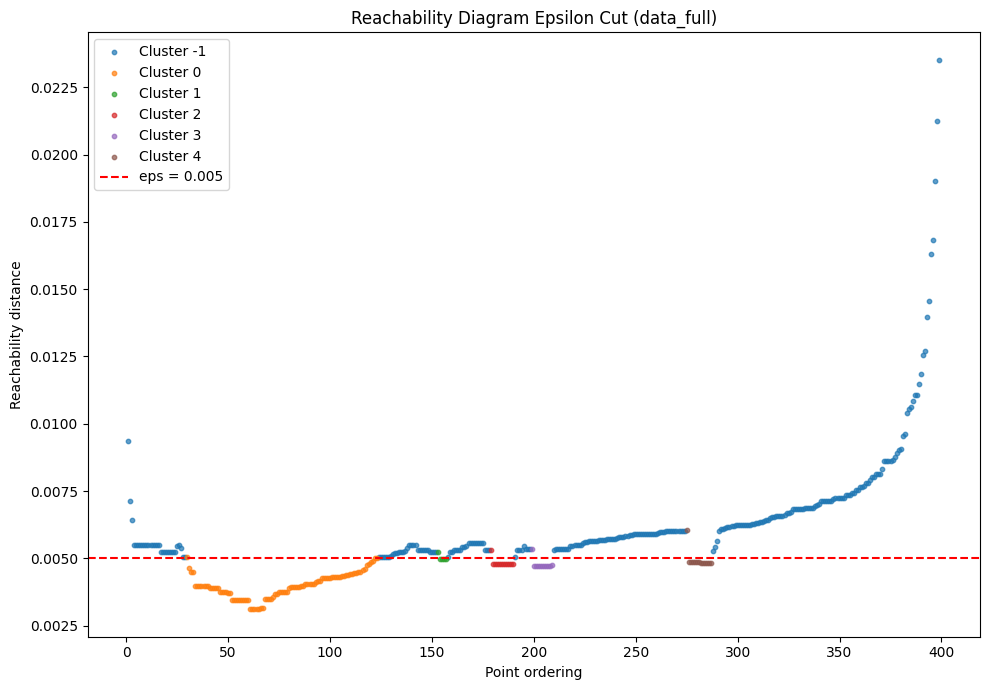

Number of Clusters: 2 for Epsilon Value 0.006


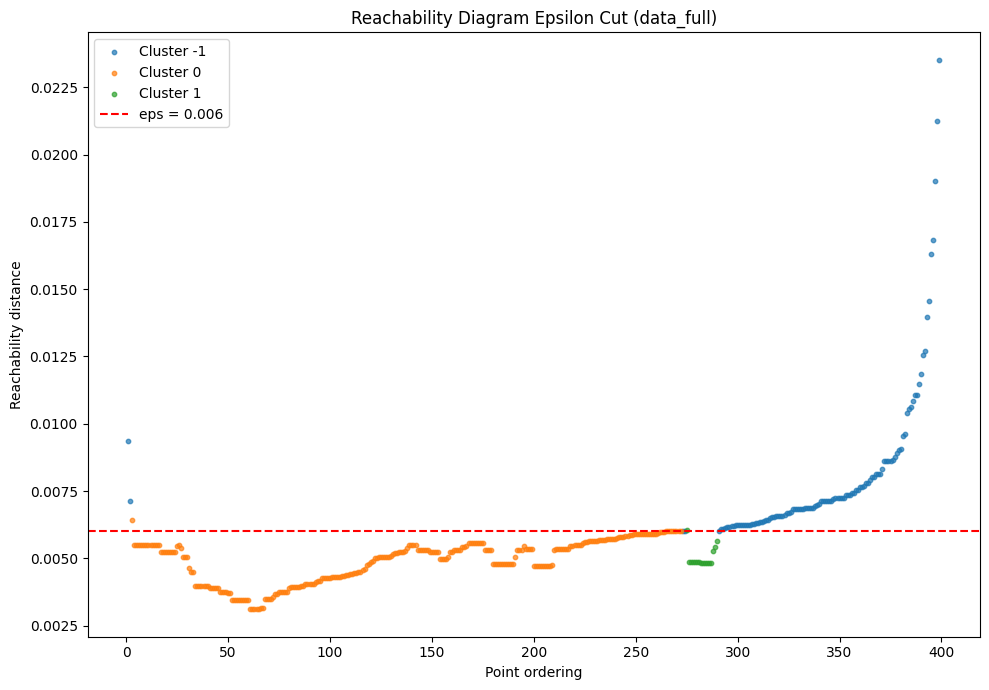

Number of Clusters: 1 for Epsilon Value 0.0072


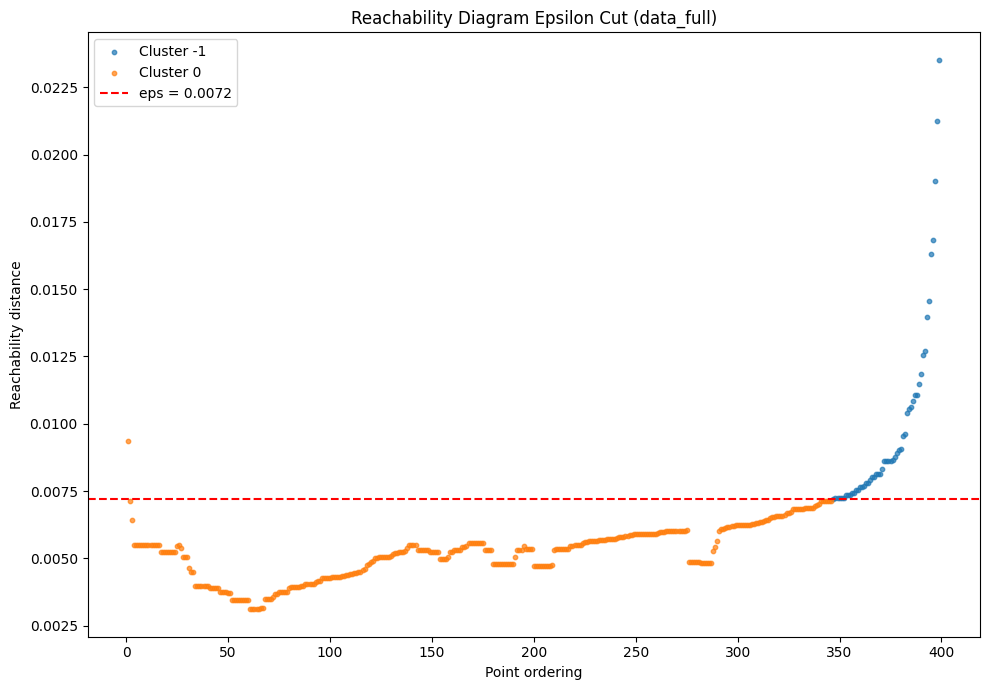

Number of Clusters: 1 for Epsilon Value 0.01


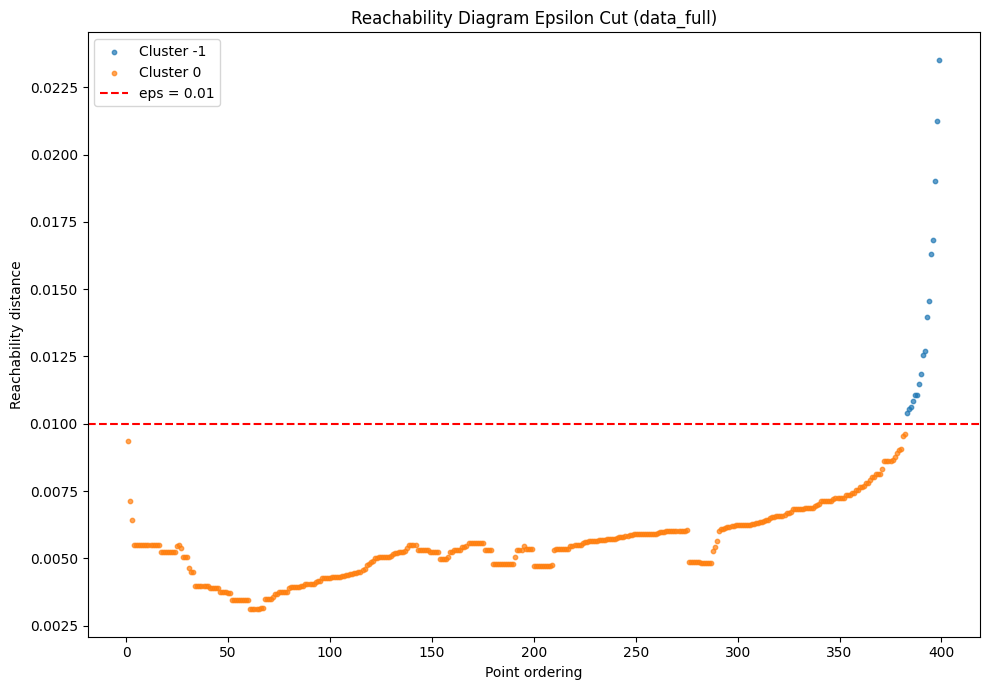

In [31]:
eps_values = [0.005, 0.006, 0.0072, 0.01] # list of epsilon values to iterate over; derived from above plot

for eps_value in eps_values: 
    labels_eps = cluster_optics_dbscan(
        reachability=optics.reachability_,
        core_distances=optics.core_distances_,
        ordering=optics.ordering_,
        eps=eps_value,
    ) # Using dbscal to create epsilon cuts

    ordered_labels = labels_eps[optics.ordering_] # ordering labels
    unique_labels = np.unique(labels_eps) # unique labels 
    num_c = len(unique_labels) - 1 if -1 in unique_labels else len(unique_labels) # number of clusters, -1 is always noise
    print(f"Number of Clusters: {num_c} for Epsilon Value {eps_value}")

    labels = labels_eps
    plt.figure(figsize=(10, 7))
    for c in unique_labels:
        mask = (ordered_labels == c)
        plt.scatter(space[mask], reachability[mask],
                    s=10, alpha=0.7, label=f"Cluster {c}") # assigning distict color to each cluster and labeling them 
    plt.axhline(y=eps_value, color='r', linestyle="--", label=f"eps = {eps_value}") # visualizing epsilon cut line 
    plt.xlabel("Point ordering")
    plt.ylabel("Reachability distance")
    plt.title("Reachability Diagram Epsilon Cut (data_full)")
    plt.tight_layout()
    plt.legend()
    plt.show()

**Epsilon Cut Evaluation**

* Setting a high epsilon value (0.1) results in only one cluster as all points aside from noise are connected tightly enough while including many points that could also be noise
* Setting very low epsilon value (0.005) creates a number of very small clusters while also producing a lot of noise points

I am choosing the **Epsilon Cut 0.006** for the dataset data_full as the most appropriate cut but with the note that I find that none of the clusterings are entirely suitable for the project. The cut at 0.006 produces two clusters, but one of them is fairly small so it could also be noise. I have chosen to include it though, because there is kind of a second more pronounced dip visible in the plot where the cluster is marked.

In [32]:
labels_full = cluster_optics_dbscan(
        reachability=optics.reachability_,
        core_distances=optics.core_distances_,
        ordering=optics.ordering_,
        eps=0.006) # assigning chosen epsilon cut clustering to labels_full

### Clustering Analysis of PCA transformed data

<div class="alert alert-block alert-warning"> 
<b>Choice of Distance Function</b>: 
Choose the distance function for the pca transformed data clustering. Explain!
    
(Choice + 1-3 bullet points in the cell below)
</div>

My Choice: Euclidean Distance

* Does not ignore magnitudes like Cosine Similarity 
* Makes differences between for example 4 hours and 6 hours of leisure screen time
* Usable for scaled and dimensionality reduced data

<div class="alert alert-block alert-warning"> 
Clustering of <code>data_pca</code>:

(Commented code + bullet points, add cells below)
</div>

**Reachability plot**

* Reachbility plot to visualize OPTICS reachability 
* Using parameters derived from experiments in the draft 

Number of clusters: 1


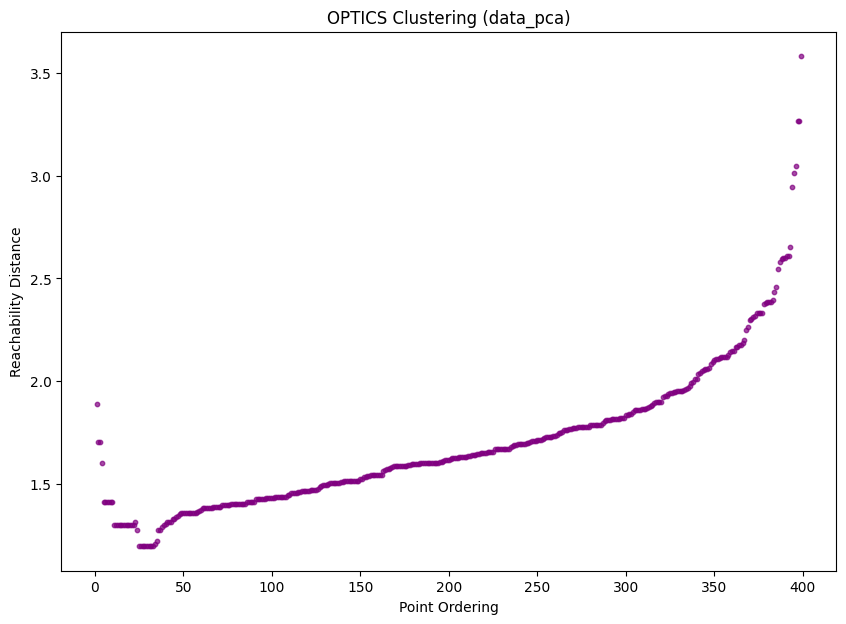

In [33]:
optics = OPTICS(min_samples=15, min_cluster_size=0.05, metric="euclidean") # parameter values derived from draft 
optics_clusters=optics.fit_predict(data_pca) # fitting and predicting
clusters = np.unique(optics_clusters) # unique clusters
num_c = len(clusters) - 1 if -1 in clusters else len(clusters) # number of clusters, -1 is always noise
print(f"Number of clusters: {num_c}") # print the number of clusters

ordered_labels = optics.labels_[optics.ordering_] # ordering labels
reachability = optics.reachability_[optics.ordering_] # calculating reachability 
space = np.arange(len(data_pca))
plt.figure(figsize=(10, 7))
plt.scatter(space, reachability, s=10, alpha=0.7, color="purple") # plot reachability plot
plt.xlabel("Point Ordering")
plt.ylabel("Reachability Distance")
plt.title("OPTICS Clustering (data_pca)")
plt.show()

**Distance Cuts**

Number of Clusters: 1 for Epsilon Value 1.25


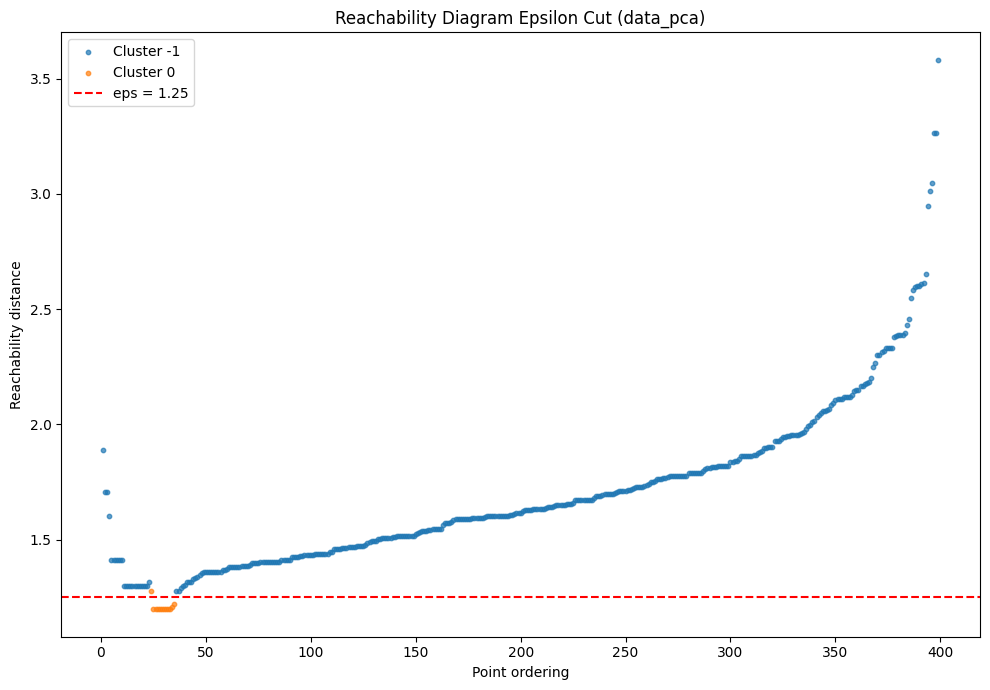

Number of Clusters: 2 for Epsilon Value 1.3


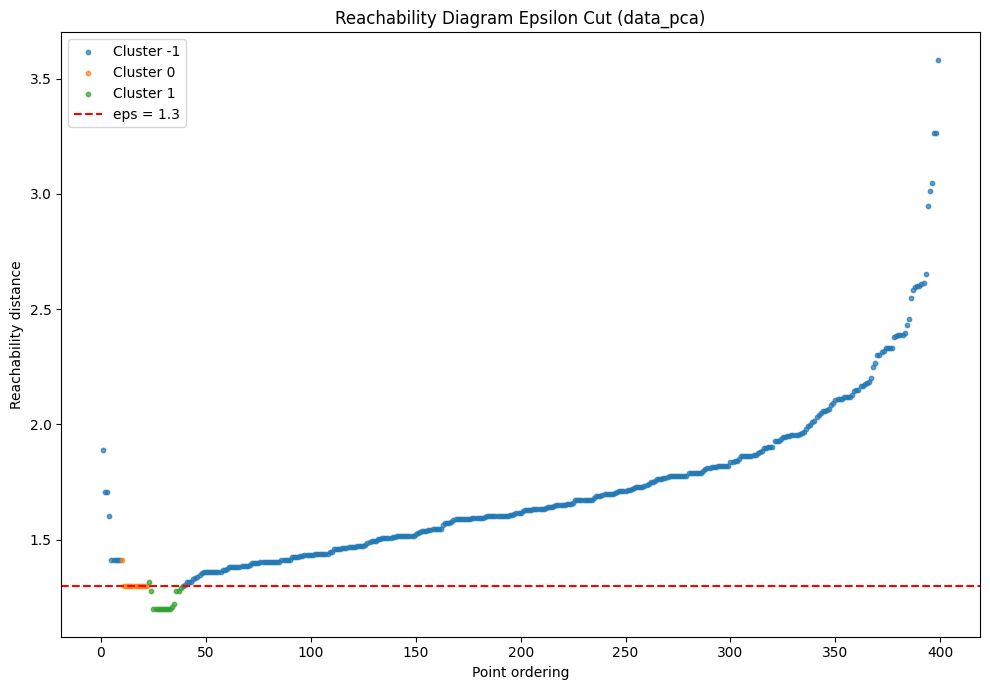

Number of Clusters: 1 for Epsilon Value 1.4


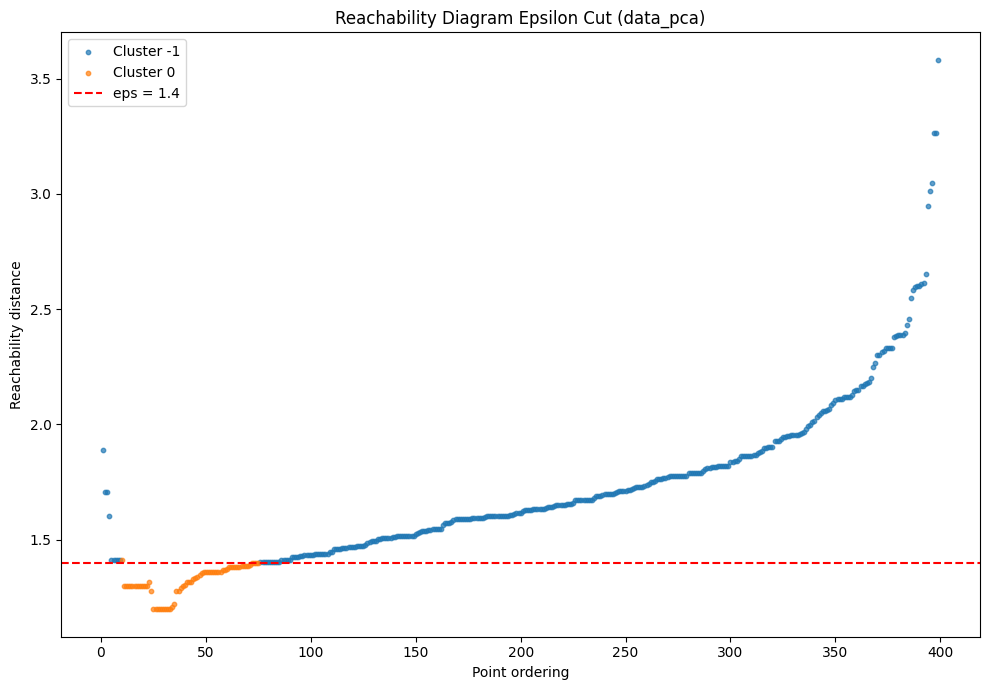

Number of Clusters: 1 for Epsilon Value 1.8


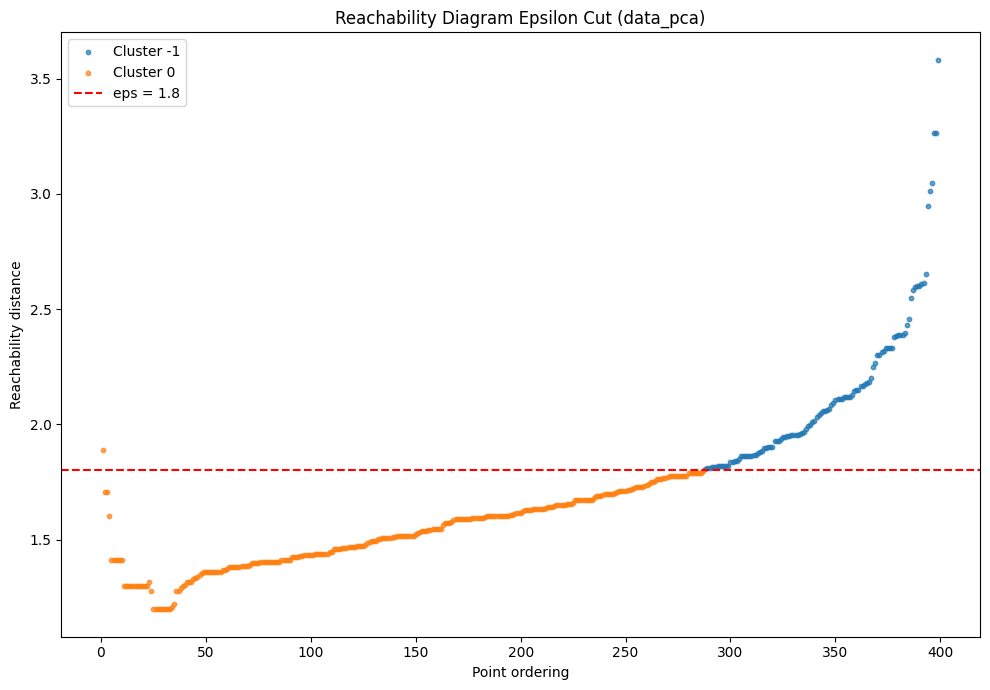

In [34]:
eps_values = [1.25, 1.3, 1.4, 1.8] # epsilon values to iterate over

for eps_value in eps_values: 
    labels_eps = cluster_optics_dbscan(
        reachability=optics.reachability_,
        core_distances=optics.core_distances_,
        ordering=optics.ordering_,
        eps=eps_value,
    ) # applying dbscan derived from optics clustering with epsilon cut

    ordered_labels = labels_eps[optics.ordering_] # ordering lables
    unique_labels = np.unique(labels_eps) # unique cluster labels
    num_c = len(unique_labels) - 1 if -1 in unique_labels else len(unique_labels) # number of clusters, -1 is always noise
    print(f"Number of Clusters: {num_c} for Epsilon Value {eps_value}")

    labels = labels_eps
    plt.figure(figsize=(10, 7))
    for c in unique_labels:
        mask = (ordered_labels == c)
        plt.scatter(space[mask], reachability[mask],
                    s=10, alpha=0.7, label=f"Cluster {c}") # assigning distinc color to each cluster and labeling 
    plt.axhline(y=eps_value, color="r", linestyle="--", label=f"eps = {eps_value}") # visualizing epsilon cut line 
    plt.xlabel("Point ordering")
    plt.ylabel("Reachability distance")
    plt.title("Reachability Diagram Epsilon Cut (data_pca)")
    plt.tight_layout()
    plt.legend()
    plt.show()

**Epsilon Cut Evaluation**

* Setting a high epsilon value (1.8) results in only one cluster as all points aside from noise are connected tightly enough while including many points that could also be noise
* Setting a medium epsilon value (1.3) creates a very small second cluster that is probably rather noise

I am choosing the **Epsilon Cut 1.25** for the dataset data_pca as the most appropriate cut, as it produces one cluster and a lot of noise, which aligns with the structure of the reachability plot.

In [35]:
labels_pca = cluster_optics_dbscan(
        reachability=optics.reachability_,
        core_distances=optics.core_distances_,
        ordering=optics.ordering_,
        eps=1.25) # assigning chosen clustering with epsilon cut to labels_pca

### Clustering Analysis of Variance Threshold transformed data

<div class="alert alert-block alert-warning"> 
<b>Choice of Distance Function</b>: 
Choose the distance function for the variance threshold transformed data clustering. Explain!
    
(Choice + 1-3 bullet points in the cell below)
</div>

My Choice: Euclidean Distance

* Same reasons as for pca: does not ignore magnitude of features
* Works on scaled and reduced data
* Data_vt has even less dimensions compared to data_pca --> Euclidean Distance is suitable

<div class="alert alert-block alert-warning"> 
Clustering of <code>data_vt</code>:

(Commented code + bullet points, add cells below)
</div>

**Reachability plot**

* Reachbility plot to visualize OPTICS reachability 
* Using parameters derived from experiments in the draft 

Number of clusters: 2


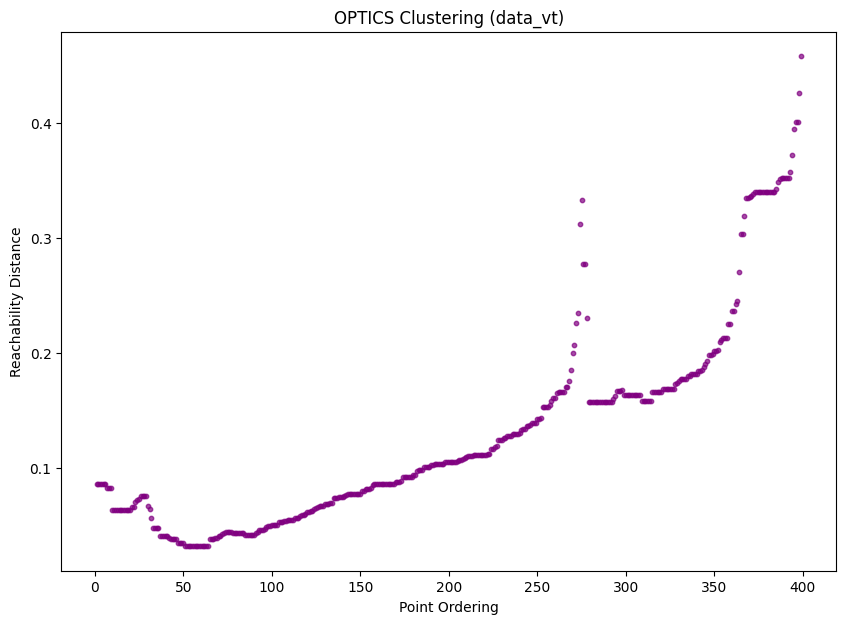

In [36]:
optics = OPTICS(min_samples=15, min_cluster_size=0.05, metric='euclidean') # parameter values derived from draft 
optics_clusters=optics.fit_predict(data_vt) # fitting and predicting
clusters = np.unique(optics_clusters) # unique clusters
num_c = len(clusters) - 1 if -1 in clusters else len(clusters) # number of clusters, -1 is always noise
print(f"Number of clusters: {num_c}") # print the number of clusters

ordered_labels = optics.labels_[optics.ordering_] # order labels 
reachability = optics.reachability_[optics.ordering_] # calculate reachabilites
space = np.arange(len(data_vt))
plt.figure(figsize=(10, 7))
plt.scatter(space, reachability, s=10, alpha=0.7, color="purple") # plot reachability pot
plt.xlabel("Point Ordering")
plt.ylabel("Reachability Distance")
plt.title("OPTICS Clustering (data_vt)")
plt.show()

**Distance Cuts**

Number of Clusters: 1 for Epsilon Value 0.1


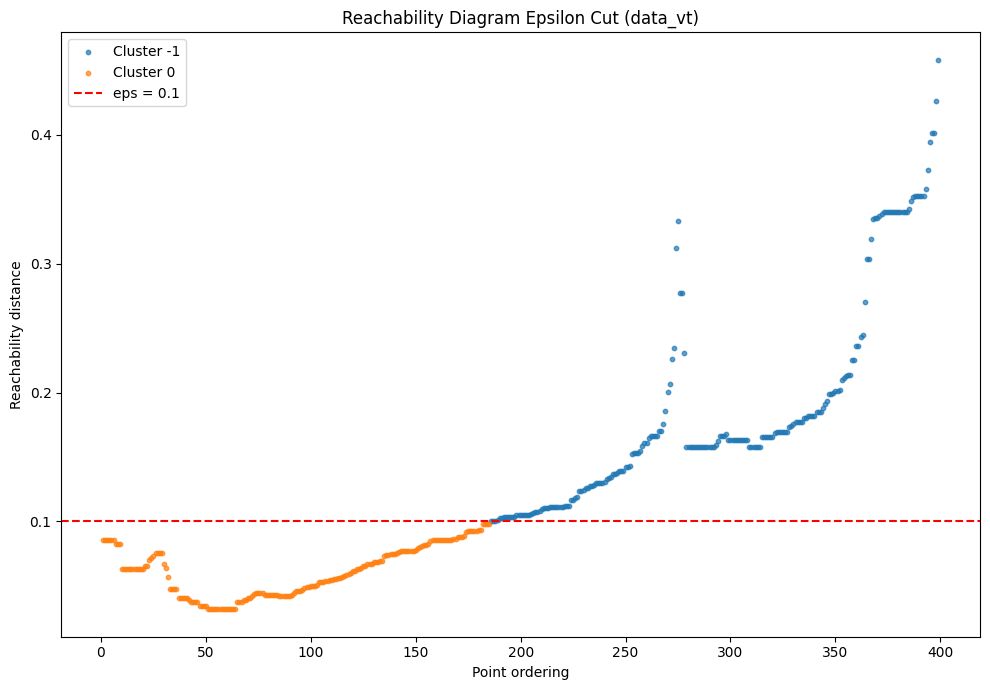

Number of Clusters: 2 for Epsilon Value 0.2


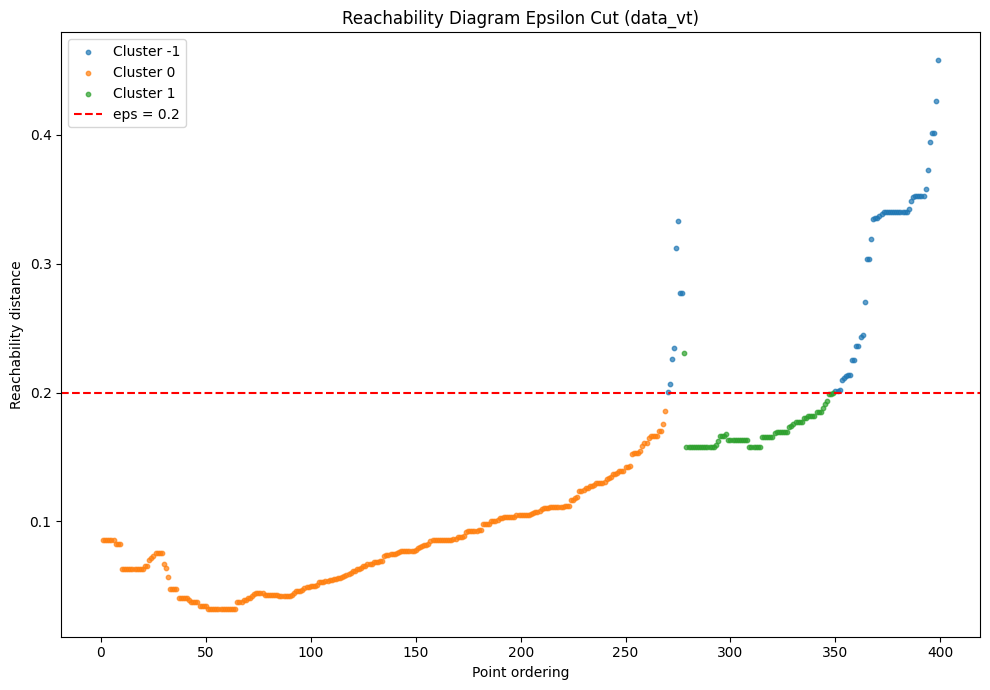

Number of Clusters: 2 for Epsilon Value 0.3


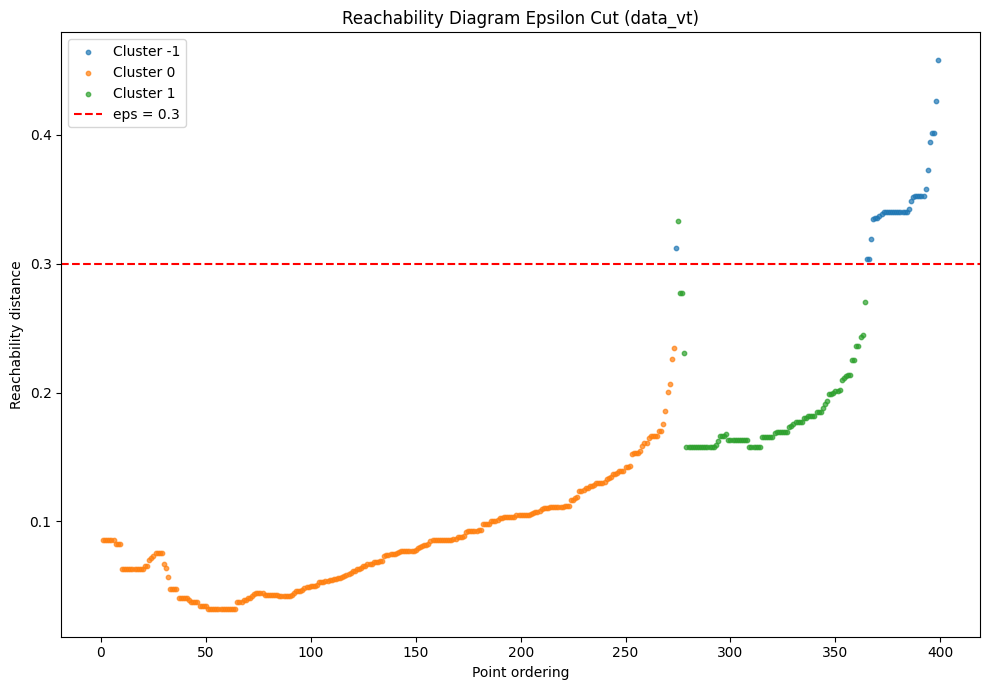

Number of Clusters: 1 for Epsilon Value 0.35


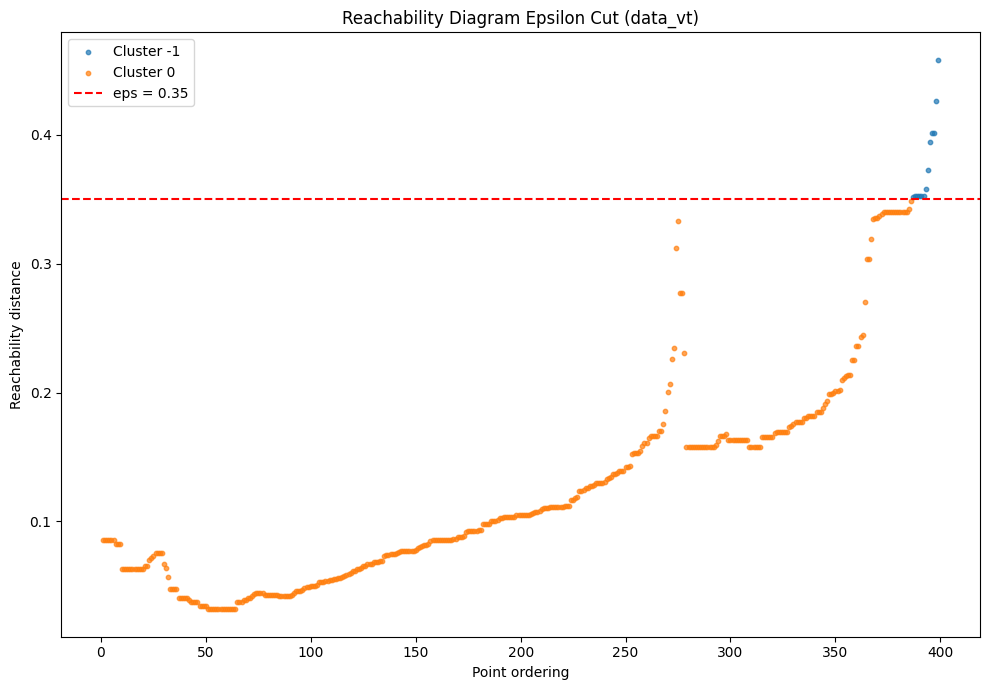

In [37]:
eps_values = [0.1, 0.2, 0.3, 0.35]  # epsilon values to iterate over, derived from above reachability diagram

for eps_value in eps_values: 
    labels_eps = cluster_optics_dbscan(
        reachability=optics.reachability_,
        core_distances=optics.core_distances_,
        ordering=optics.ordering_,
        eps=eps_value,
    ) # applying dbscan epsilon cut clustering derived from OPTICS

    ordered_labels = labels_eps[optics.ordering_] # ordering labels
    unique_labels = np.unique(labels_eps) # unique cluster labels
    num_c = len(unique_labels) - 1 if -1 in unique_labels else len(unique_labels) # number of clusters, -1 is always noise
    print(f"Number of Clusters: {num_c} for Epsilon Value {eps_value}")

    labels = labels_eps
    plt.figure(figsize=(10, 7))
    for c in unique_labels:
        mask = (ordered_labels == c)
        plt.scatter(space[mask], reachability[mask],
                    s=10, alpha=0.7, label=f"Cluster {c}") # assigning unique color to clusters and labeling them
    plt.axhline(y=eps_value, color="r", linestyle="--", label=f"eps = {eps_value}") # visualizing epsilon cut line 
    plt.xlabel("Point ordering")
    plt.ylabel("Reachability distance")
    plt.title("Reachability Diagram Epsilon Cut (data_vt)")
    plt.tight_layout()
    plt.legend()
    plt.show()

**Epsilon Cut Evaluation**

* Setting a high epsilon value (0.35) results in only one cluster as all points aside from noise are connected tightly enough
* Setting a low epsilon value (0.1) ignores many points that could be in a cluster as it only clusters very tightly connected samples

I am choosing the **Epsilon Cut 0.2** for the dataset data_vt as the most appropriate cut, as it produces two clusters that align with the structure of the reachability plot, since there are two clear dips in the plot. At the same time it correctly assigns noise points.

In [38]:
labels_vt = cluster_optics_dbscan(
        reachability=optics.reachability_,
        core_distances=optics.core_distances_,
        ordering=optics.ordering_,
        eps=0.2) # assigning chosen clustering and epsilon cut to labels_vt 

# Task 8 -- Clustering Comparison

<div class="alert alert-block alert-warning"> 
<b>Comparison</b>: 
Compare the three clusterings from the previous task as described in Task 8.

(Commented code + bullet points, add cells below)
</div>

**Comparison Tables and Metrics:**

Creating tables to showcase "how the different clusters are related with respect to the membership of the data instances"

**Comparing FULL vs PCA**

In [39]:
# Crosstab of data_full and data_pca
table_full_pca = pd.crosstab(labels_full, labels_pca) # creating crosstab
table_full_pca.index.name="FULL" # labeling 
table_full_pca.columns.name="PCA" # labeling
table_full_pca

PCA,-1,0
FULL,,
-1,114,0
0,258,12
1,16,0


In [40]:
# Mutual Information
mutual_info_score(labels_full, labels_pca) # code from https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mutual_info_score.html

0.012013477623947166

In [41]:
# Rand Index
rand_score(labels_full, labels_pca) # code from https://scikit-learn.org/stable/modules/generated/sklearn.metrics.rand_score.html

0.5180451127819549

**Comparing FULL vs VT**

In [42]:
# Crosstab of data_full and data_vt 
table_full_vt = pd.crosstab(labels_full, labels_vt) # creating crosstab
table_full_vt.index.name="FULL" # labeling
table_full_vt.columns.name="VT" # labeling
table_full_vt

VT,-1,0,1
FULL,,,
-1,13,89,12
0,29,181,60
1,16,0,0


In [43]:
# Mutual Information
mutual_info_score(labels_full, labels_vt)

0.09244439124728523

In [44]:
# Rand Index 
rand_score(labels_full, labels_vt)

0.5224561403508772

**Comparing PCA vs VT**

In [45]:
# Crosstab of data_pca and data_vt
table_pca_vt = pd.crosstab(labels_pca, labels_vt) # creating crosstab 
table_pca_vt.index.name="PCA" # labeling 
table_pca_vt.columns.name="VT" # labeling
table_pca_vt


VT,-1,0,1
PCA,,,
-1,58,258,72
0,0,12,0


In [46]:
# Mutual Information
mutual_info_score(labels_vt, labels_pca)

0.012013477623946944

In [47]:
# Rand Index
rand_score(labels_vt, labels_pca)

0.48857142857142855

## Comparison of the Three Clusterings

data_full:

* Not standardized nor reduced 
* A lot of noise points 
* Small second cluster that could also be noise 
* No strong distinction between clusters 

data_pca:

* Changed thresholds because of Scaling with Standard Scaler
* PCA distorts densities, therefore larger and smaller number of clusters are to be expected
* Only one cluster and a lot of noise 
* Not very meaningful 

data_vt:

* Scaled and reduced even more 
* MinMax Scaler preserves variance --> clustering on density more meaningful
* Two distinct clusters that both have a sufficient size 
* Some noise points but noise is not the majority group 
* Most viable clustering

Evaluation metrics:
* Not much overlap in clusters between all three clustering methods --> low mutual info score (below 0.1) 
* "Best" mutual info score: data_full and data_vt 0.092 --> still very low 
* Rand index mediocre: between 0.45 and 0.52, could also be chance agreement
* Low to medium similarities --> Can be seen across all three metrics
* Every version achieves very different clustering structures with different number of noise points 
* Data_pca and data_full produce a lot of noise, as seen in the crosstabs and the clustering diagrams (-1 is noise)

Advantages and drawbacks:
* data_full and data_pca have a lot of noise and only small clusters 
* data_pca uses StandardScaler which distorts variance and destroys density structures --> huge drawback for OPTICS clustering
* When data_full threshold is adjusted it could recognize more small clusters --> could be suitable for certain tasks, but not for this one
* data_vt retains variance and therefore density structures, which is an advantage in OPTICS clustering

# Task 9 -- Conclusions and Future Work

<div class="alert alert-block alert-warning"> 
<b>Subtasks</b>: 
For each subtask, create <ul>
    <li> a fitting headline in a separate cell and </li>
    <li> add markdown cells to conduct the respective task.</li>
</ul>
(bullet points, add cells below)
</div>


### 1. Final Result from Task 8

Final result: data_vt

* Because it yields the most distinct clusters
* More samples in clusters than noise 
* MinMaxScaling and Dimensionality Reduction make underlaying data most suitable for OPTICS clustering

### 2. Summary and Comparison to desired project outcomes

* For most methods, the data does not yield distinct clusters 
* Clustering more difficult than expected 
* Expected around five user groups to be able to derive mental wellness solutions for user behaviours 
* Most viable clustering method derived two distinct clusters 
* Potential interpretation could be at risk people and not at risk people --> would be a start but not the desired outcome 

### 3. Generated Value and Course of Action

* Two Clusters --> Look into wether it is people at risk and not at risk 
* That would derive value for first level support by identifying at risk users 
* Further value: Initial analysis is done and further investigations can be done from this 
* Broad understanding of data makes further steps easier

### 4. Limitations and possible pitfalls of using these results

* Clusters are very general
* Wether clusters actually are at risk and not at risk users is questionable 
* Not suitable for detailed and targeted solutions  

### 5. Ideas for future work

* Could use HDBSCAN because it might be more robust with the noise in the data 
* Select feature based on domain knowledge and their meaning and not only because of statistical analysis (a combination is also possible)
* If possible, try a larger dataset, because some methods found various small clusters --> might be worth exploring wether those get larger with larger dataset or wether they are just groups of noise

### 6. Discussion of employed methodology

* Data_vt seems to achieve the best results, especially in OPTICS and HAC clustering 
* I chose OPTICs, which is the same choise as given in this template 
* I have chosen a distance function for the task but choosing one dataset at somepoint and experimenting with distance functions could have been a good choice
* Concentrate on most viable dataset for each clustering algorithm after a few experiments to achieve best possible outcome

### 7. Critical reflection 

* Original task might have been to idealistic 
* Identifying at risk and not at risk users could have been a better approach
* The original idea would create more value if successful
* In total, not a bad idea but maybe too much or the data was not suitable enough 